# 02 · Residual analysis

Does removing the PCA factors leave something mean-reverting to trade? This reads the residual panel
(`sharpee.pipeline.load_panel`) and the OU positions saved by `scripts/run_baseline.py`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sharpee.config import load_config, repo_path
from sharpee.data.preprocess import MarketData
from sharpee.features.diagnostics import autocorr, daily_residuals, raw_returns, residual_report
from sharpee.pipeline import load_panel, runs_dir
from sharpee.strategies.ou_strategy import ou_fit, ou_positions

plt.rcParams.update({"figure.figsize": (9, 3.5), "axes.grid": True, "grid.alpha": 0.3})
FIGURES = repo_path("reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)


def save(fig, name):
    """Keep a copy in reports/figures for the write-up."""
    fig.savefig(FIGURES / f"{name}.png", dpi=120, bbox_inches="tight")


cfg = load_config("data", "experiment", "baseline")
panel = load_panel(cfg)
md = MarketData.load(repo_path(cfg["processed_dir"]))
K = cfg["n_factors"]
print(f"{len(panel.dates)} decision dates ({panel.dates[0].date()} to {panel.dates[-1].date()}), "
      f"{panel.n_slots} universe slots, {len(panel.phi)} monthly factor models with K = {K}")

4215 decision dates (2009-04-01 to 2025-12-31), 150 universe slots, 201 monthly factor models with K = 5


## 1. How much do the factors explain?

Share of the correlation matrix's variance captured by the first eigenvector (roughly the market)
and by all K factors, at each monthly refit.

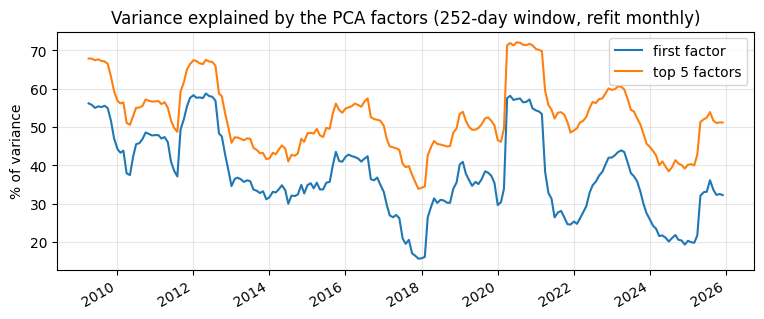

,first factor,top 5 factors
mean,37.4,52.4
min,15.6,33.8
max,58.8,72.1


In [2]:
r = md.returns.to_numpy()
refit_rows = md.returns.index.get_indexer(panel.dates[panel.month_start])
shares = []
for m, k in enumerate(refit_rows):
    ids = panel.universe[m][panel.universe[m] >= 0]
    window = np.nan_to_num(r[k - cfg["pca_window"]:k, ids])
    ev = np.linalg.eigvalsh(np.corrcoef(window, rowvar=False))[::-1]
    shares.append([ev[0] / ev.sum(), ev[:K].sum() / ev.sum()])
shares = pd.DataFrame(shares, index=panel.dates[panel.month_start],
                      columns=["first factor", f"top {K} factors"]) * 100

ax = shares.plot()
ax.set_ylabel("% of variance")
ax.set_title("Variance explained by the PCA factors (252-day window, refit monthly)")
save(ax.figure, "02_factor_variance")
plt.show()
shares.describe().loc[["mean", "min", "max"]].round(1)

On average the first factor explains about 37% of the variance and the top 5 about 52%. Both rise when correlations spike (2011-12, 2020) and fall in calm, dispersed markets (2017-18, 2024). In a crisis stocks move together, so there is less stock-specific movement left to trade.

## 2. Raw returns vs residuals

Correlation with the market should collapse after factor removal; what is left is the stock-specific
part the strategies trade.

In [3]:
periods = {"2010-2019": panel.index_of("2010-01-01", "2019-12-31"),
           "2020-2023": panel.index_of("2020-01-01", "2023-12-31")}
pd.DataFrame({name: residual_report(panel, idx, cfg["window"], cfg["kappa_min"])
              for name, idx in periods.items()}).round(3)

,2010-2019,2020-2023
raw: mean |corr| with market,0.584,0.611
residual: mean |corr| with market,0.023,0.056
residual / raw variance,0.525,0.434
raw: lag-1 autocorrelation,-0.013,-0.066
residual: lag-1 autocorrelation,-0.008,-0.007
OU fits that mean-revert (0<b<1),0.954,0.956
OU fits passing the kappa filter,0.785,0.791
median OU half-life (days),8.569,8.532


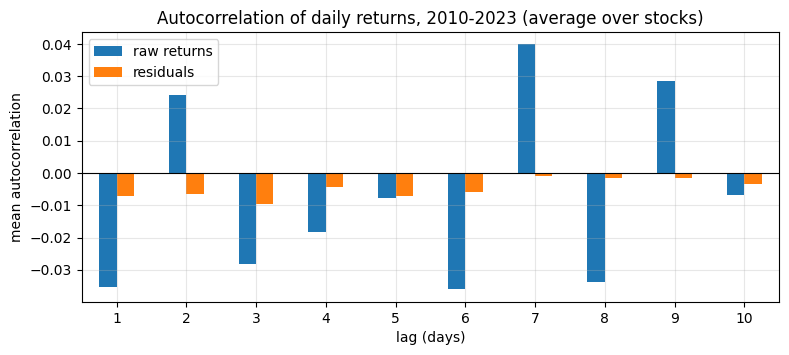

In [4]:
idx = panel.index_of("2010-01-01", "2023-12-31")
eps, raw = daily_residuals(panel, idx), raw_returns(panel, idx)
lags = range(1, 11)
acf = pd.DataFrame({"raw returns": [autocorr(raw, k) for k in lags],
                    "residuals": [autocorr(eps, k) for k in lags]}, index=lags)
ax = acf.plot.bar(rot=0)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("lag (days)")
ax.set_ylabel("mean autocorrelation")
ax.set_title("Autocorrelation of daily returns, 2010-2023 (average over stocks)")
save(ax.figure, "02_residual_autocorrelation")
plt.show()

Raw-return autocorrelations swing between positive and negative from lag to lag. That pattern is market-wide: it disappears once the factors are removed. Residual autocorrelation is small (about -0.01) but **negative at every lag from 1 to 10 days**. One day's reversal is negligible, but it accumulates over one to two weeks, which matches the OU half-lives below.

## 3. Mean-reversion speed

The OU fit on each stock's 60-day cumulative residual gives a reversion speed kappa; the half-life is
ln(2)/kappa. The baseline only trades stocks whose half-life is under about 21 trading days (kappa > 252/30).

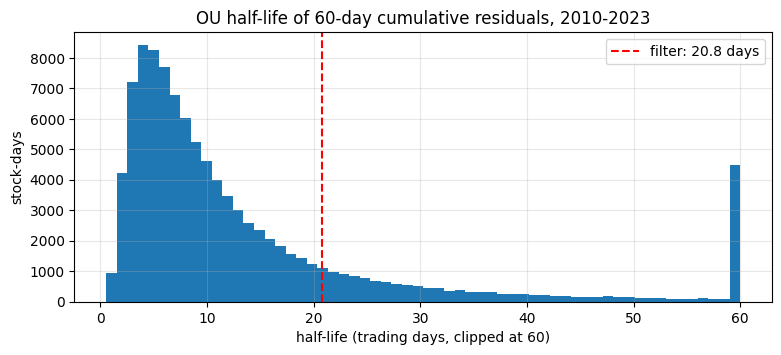

median half-life 8.6 days; 83% of mean-reverting fits pass the filter


In [5]:
sample = panel.index_of("2010-01-01", "2023-12-31")[::5]
_, kappa, valid = ou_fit(panel.windows(sample, cfg["window"]))
ok = valid & panel.tradable[sample]
half_life = np.log(2) / kappa[ok] * 252
cutoff = np.log(2) / cfg["kappa_min"] * 252

fig, ax = plt.subplots()
ax.hist(np.clip(half_life, 0, 60), bins=60)
ax.axvline(cutoff, color="red", ls="--", label=f"filter: {cutoff:.1f} days")
ax.set_xlabel("half-life (trading days, clipped at 60)")
ax.set_ylabel("stock-days")
ax.set_title("OU half-life of 60-day cumulative residuals, 2010-2023")
ax.legend()
save(fig, "02_ou_half_life")
plt.show()
print(f"median half-life {np.median(half_life):.1f} days; "
      f"{(half_life < cutoff).mean():.0%} of mean-reverting fits pass the filter")

## 4. One stock, one year: the s-score in action

The stock that changed OU position most often in 2021, among those in the universe all year.
Green = long the residual, red = short.

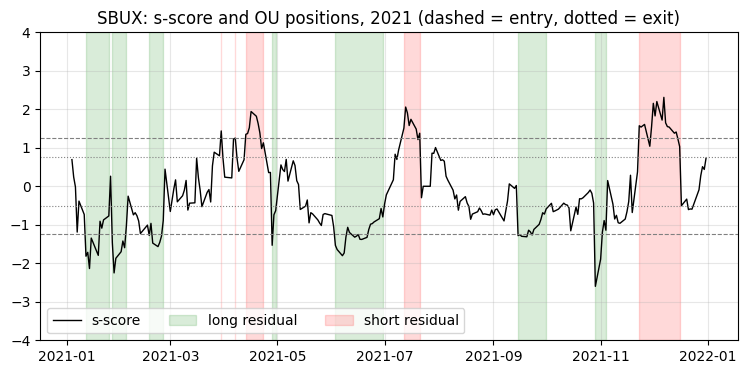

SBUX: 24 position changes in 2021


In [6]:
scores_file = runs_dir(cfg) / "scores_ou.npz"
if scores_file.exists():
    pos = np.load(scores_file)["scores"]
else:  # run_baseline.py not run yet: compute the same positions here
    pos = ou_positions(panel, np.arange(len(panel.dates)), window=cfg["window"], entry=cfg["entry"],
                       exit_short=cfg["exit_short"], exit_long=cfg["exit_long"], kappa_min=cfg["kappa_min"])

year = panel.index_of("2021-01-01", "2021-12-31")
uni = panel.universe[panel.month[year]]
all_year = [g for g in np.unique(uni[uni >= 0]) if (uni == g).any(axis=1).all()]
changes = {g: np.abs(np.diff(pos[year, (uni == g).argmax(axis=1)])).sum() for g in all_year}
g = max(changes, key=changes.get)
slot = (uni == g).argmax(axis=1)
s_all, _, _ = ou_fit(panel.windows(year, cfg["window"]))
s = s_all[np.arange(len(year)), slot]
p = pos[year, slot]
d = panel.dates[year]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(d, s, color="black", lw=1, label="s-score")
for level, style in [(cfg["entry"], "--"), (-cfg["entry"], "--"), (cfg["exit_short"], ":"), (cfg["exit_long"], ":")]:
    ax.axhline(level, color="grey", ls=style, lw=0.8)
ax.fill_between(d, -4, 4, where=p > 0, color="green", alpha=0.15, step="post", label="long residual")
ax.fill_between(d, -4, 4, where=p < 0, color="red", alpha=0.15, step="post", label="short residual")
ax.set_ylim(-4, 4)
ax.set_title(f"{panel.tickers[g]}: s-score and OU positions, 2021 (dashed = entry, dotted = exit)")
ax.legend(loc="lower left", ncol=3)
save(fig, "02_sscore_example")
plt.show()
print(f"{panel.tickers[g]}: {int(changes[g])} position changes in 2021")

## 5. Universe churn

Names that leave the universe at a monthly refit have their positions closed, which costs money.

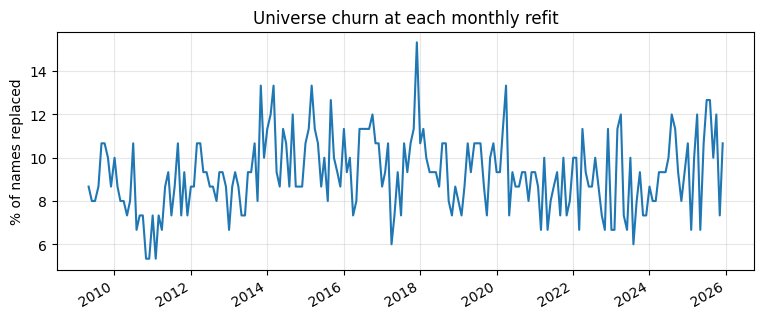

average churn 9.3% of names per month


In [7]:
u = panel.universe
churn = pd.Series(
    [1 - len(set(u[m][u[m] >= 0]) & set(u[m - 1][u[m - 1] >= 0])) / (u[m] >= 0).sum() for m in range(1, len(u))],
    index=panel.dates[panel.month_start[1:]]) * 100
ax = churn.plot()
ax.set_ylabel("% of names replaced")
ax.set_title("Universe churn at each monthly refit")
save(ax.figure, "02_universe_churn")
plt.show()
print(f"average churn {churn.mean():.1f}% of names per month")

## Takeaways

- **Factor removal works.** Average correlation with the market falls from about 0.6 to 0.02-0.06, and residuals keep roughly half of each stock's variance.
- **There is mean reversion to trade, but it is thin.** Residual autocorrelation is small and negative across lags 1-10, and the typical OU half-life is about 8-9 trading days.
- **Costs decide the outcome.** The signal needs frequent trading (about 24% of the book per day for the OU baseline), and about 9% of the universe is replaced at each monthly refit. `scripts/run_baseline.py` shows the result: Sharpe 0.94 before costs, 0.15 after 5 bps and -0.65 after 10 bps.
- **The question for Phase 2:** can a model trained directly on Sharpe after costs keep this signal while trading less?